Initializing Model. From subgraph_data.pkl load:
dict_keys(['fln_mat', 'sln_mat', 'hier_vals', 'areas'])
Running network with stimulation to V1
Figure saved at reproduce_fig3.pdf


<Figure size 400x400 with 0 Axes>

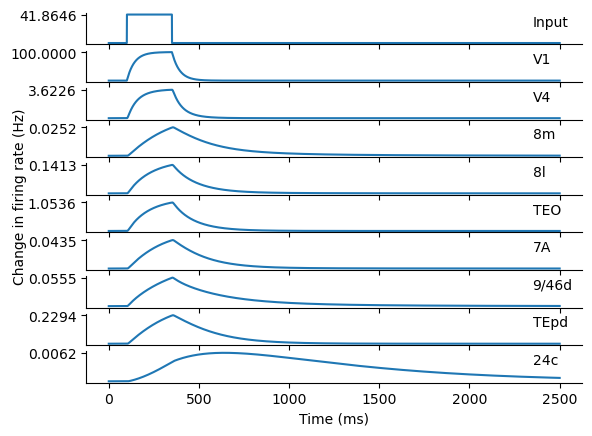

In [1]:
# -*- coding: utf-8 -*-
"""
A replication of
Chaudhuri, Rishidev, et al.
"A large-scale circuit mechanism for hierarchical dynamical processing in the primate cortex."
Neuron 88.2 (2015): 419-431.

Figure 3A can not be reproduced exactly because the parameters used to generate
the figure in original paper is of higher precision than the parameters reported.

@author: Guangyu Robert Yang, 2015/11
"""
from __future__ import division

import pickle
import numpy as np
import matplotlib.pyplot as plt


class Model(object):
    """
    A model of multiple interacting brain areas from Chaudhuri et al. Neuron 2015

    """
    def __init__(self, datafile='subgraph_data.pkl', ext_params={}):
        #---------------------------------------------------------------------------------
        # Loading Anatomical Data from Kennedy's group
        #---------------------------------------------------------------------------------
        
        try:
            with open(datafile,'rb') as f:
                p = pickle.load(f)
        except UnicodeDecodeError:  # Python 3 compatibility
            with open(datafile,'rb') as f:
                p = pickle.load(f, encoding='latin1')

        print('Initializing Model. From ' + datafile + ' load:')
        print(p.keys())

        p['hier_vals'] = p['hier_vals']/max(p['hier_vals']) # Normalized between 0 and 1
        p['n_area'] = len(p['areas'])

        #---------------------------------------------------------------------------------
        # Network Parameters
        #---------------------------------------------------------------------------------

        p['beta_exc'] = 0.066  # Hz/pA
        p['beta_inh'] = 0.351  # Hz/pA
        p['tau_exc'] = 20  # ms
        p['tau_inh'] = 10  # ms
        p['wEE'] = 24.3  # pA/Hz
        p['wIE'] = 12.2  # pA/Hz
        p['wEI'] = 19.7  # pA/Hz
        p['wII'] = 12.5  # pA/Hz
        p['muEE'] = 33.7  # pA/Hz
        p['muIE'] = 25.3  # pA/Hz
        p['eta'] = 0.68
        
        for key, value in ext_params.items():
            p[key] = value

        self.fI = lambda x : x*(x>0) # f-I curve

        p['exc_scale'] = (1+p['eta']*p['hier_vals'])
        self.p = p

    def run_stimulus(self, plotfile='ReplicateChaudhuri2015_Fig3A.pdf'):

        area_act = 'V1'
        print('Running network with stimulation to ' + area_act)

        #---------------------------------------------------------------------------------
        # Redefine Parameters
        #---------------------------------------------------------------------------------

        p = self.p

        # Definition of combined parameters

        local_EE = p['beta_exc'] * p['wEE'] * p['exc_scale']
        local_EI = -p['beta_exc'] * p['wEI']
        local_IE =  p['beta_inh'] * p['wIE'] * p['exc_scale']
        local_II = -p['beta_inh'] * p['wII']

        fln_scaled = (p['exc_scale'] * p['fln_mat'].T).T

        #---------------------------------------------------------------------------------
        # Simulation Parameters
        #---------------------------------------------------------------------------------

        dt = 0.2   # ms
        T = 2500  # ms
        t_plot = np.linspace(0, T, int(T/dt)+1)
        n_t = len(t_plot)

        # From target background firing inverts background inputs
        r_exc_tgt = 10 * np.ones(p['n_area'])
        r_inh_tgt = 35 * np.ones(p['n_area'])

        longrange_E = np.dot(fln_scaled,r_exc_tgt)
        I_bkg_exc = r_exc_tgt - (local_EE*r_exc_tgt + local_EI*r_inh_tgt
                                 + p['beta_exc']*p['muEE']*longrange_E)
        I_bkg_inh = r_inh_tgt - (local_IE*r_exc_tgt + local_II*r_inh_tgt
                                 + p['beta_inh']*p['muIE']*longrange_E)

        # Set stimulus input
        I_stim_exc = np.zeros((n_t,p['n_area']))

        area_stim_idx = p['areas'].index(area_act) # Index of stimulated area
        time_idx = (t_plot>100) & (t_plot<=350)
        I_stim_exc[time_idx, area_stim_idx] = 41.8646
        # Above value chosen so that V1 is driven up to 100 Hz

        #---------------------------------------------------------------------------------
        # Storage
        #---------------------------------------------------------------------------------

        r_exc = np.zeros((n_t,p['n_area']))
        r_inh = np.zeros((n_t,p['n_area']))

        #---------------------------------------------------------------------------------
        # Initialization
        #---------------------------------------------------------------------------------

        # Set activity to background firing
        r_exc[0] = r_exc_tgt
        r_inh[0] = r_inh_tgt

        #---------------------------------------------------------------------------------
        # Running the network
        #---------------------------------------------------------------------------------

        for i_t in range(1, n_t):
            longrange_E = np.dot(fln_scaled,r_exc[i_t-1])
            I_exc = (local_EE*r_exc[i_t-1] + local_EI*r_inh[i_t-1] +
                     p['beta_exc'] * p['muEE'] * longrange_E +
                     I_bkg_exc + I_stim_exc[i_t])

            I_inh = (local_IE*r_exc[i_t-1] + local_II*r_inh[i_t-1] +
                     p['beta_inh'] * p['muIE'] * longrange_E + I_bkg_inh)

            d_r_exc = -r_exc[i_t-1] + self.fI(I_exc)
            d_r_inh = -r_inh[i_t-1] + self.fI(I_inh)

            r_exc[i_t] = r_exc[i_t-1] + d_r_exc * dt/p['tau_exc']
            r_inh[i_t] = r_inh[i_t-1] + d_r_inh * dt/p['tau_inh']

        #---------------------------------------------------------------------------------
        # Plotting the results
        #---------------------------------------------------------------------------------

        _ = plt.figure(figsize=(4,4))
        area_name_list = ['V1','V4','8m','8l','TEO','7A','9/46d','TEpd','24c']
        area_idx_list = [-1]+[p['areas'].index(name) for name in area_name_list]
        f, ax_list = plt.subplots(len(area_idx_list), sharex=True)

        for ax, area_idx in zip(ax_list, area_idx_list):
            if area_idx < 0:
                y_plot = I_stim_exc[:, area_stim_idx]
                txt = 'Input'
            else:
                y_plot = r_exc[:,area_idx]
                txt = p['areas'][area_idx]

            y_plot = y_plot - y_plot.min()
            ax.plot(t_plot, y_plot)
            ax.text(0.9, 0.6, txt, transform=ax.transAxes)

            ax.set_yticks([y_plot.max()])
            ax.set_yticklabels(['{:0.4f}'.format(y_plot.max())])
            ax.spines["right"].set_visible(False)
            ax.spines["top"].set_visible(False)
            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('left')

        f.text(0.01, 0.5, 'Change in firing rate (Hz)', va='center', rotation='vertical')
        ax.set_xlabel('Time (ms)')

        if plotfile is not None:
            plt.savefig(plotfile)
            print('Figure saved at ' + plotfile)
        

if __name__ == '__main__':
    model = Model()
    model.run_stimulus(plotfile='reproduce_fig3.pdf') # Run stimulation to V1
